In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv("crime_train.csv")
test = pd.read_csv("crime_test.csv")

print(train.shape)
print(test.shape)
print(train.head())

(22489, 12)
(9639, 12)
   Unnamed: 0    Num        case_filed       city  area    crime_description  \
0       19794  19795  04-04-2022 18:00     Mumbai   307     VEHICLE - STOLEN   
1       13762  13763  07-27-2021 10:00      Surat   504              ROBBERY   
2       30311  30312  06-16-2023 23:00      Thane   493              ASSAULT   
3        5043   5044  07-29-2020 03:00  Ahmedabad   169  PUBLIC INTOXICATION   
4       35008  35009  12-29-2023 16:00     Mumbai   133  PUBLIC INTOXICATION   

    age sex      weapon         domain  police_department closed  
0  63.0   X      Poison  Violent Crime               12.0     No  
1  57.0   F  Explosives  Violent Crime                3.0     No  
2  33.0   F     Firearm  Violent Crime               18.0     No  
3  76.0   F       Knife    Other Crime                3.0     No  
4  13.0   M         NaN    Other Crime               13.0     No  


In [2]:
train_processed = train.drop("Unnamed: 0", axis=1).copy()
test_processed = test.drop("Unnamed: 0", axis=1).copy()

train_processed["weapon"] = train_processed["weapon"].fillna("Unknown")
test_processed["weapon"] = test_processed["weapon"].fillna("Unknown")

train_processed["closed"] = train_processed["closed"].map({"Yes": 1, "No": 0})
test_processed["closed"] = test_processed["closed"].map({"Yes": 1, "No": 0})

In [3]:
train_processed["case_filed"] = pd.to_datetime(
    train_processed["case_filed"],
    format="%m-%d-%Y %H:%M"
)

test_processed["case_filed"] = pd.to_datetime(
    test_processed["case_filed"],
    format="%m-%d-%Y %H:%M"
)

for df in [train_processed, test_processed]:
    df["year"] = df["case_filed"].dt.year
    df["month"] = df["case_filed"].dt.month
    df["day"] = df["case_filed"].dt.day
    df["hour"] = df["case_filed"].dt.hour

train_processed = train_processed.drop("case_filed", axis=1)
test_processed = test_processed.drop("case_filed", axis=1)

In [4]:
X = train_processed.drop("closed", axis=1)
y = train_processed["closed"]

y_test = test_processed["closed"]
X_test = test_processed.drop("closed", axis=1)

In [5]:
categorical_cols = [
    "city",
    "crime_description",
    "sex",
    "weapon",
    "domain"
]

X = pd.get_dummies(X, columns=categorical_cols, dtype=int)
X_test = pd.get_dummies(X_test, columns=categorical_cols, dtype=int)

X_test = X_test.reindex(columns=X.columns, fill_value=0)

X = X.drop("Num", axis=1)
X_test = X_test.drop("Num", axis=1)

print(X.shape)
print(X_test.shape)

(22489, 71)
(9639, 71)


In [6]:
X_array = X.to_numpy(dtype=float)
y_array = y.to_numpy(dtype=float)

np.random.seed(42)
indices = np.random.permutation(len(X_array))

split = int(0.8 * len(X_array))

train_indices = indices[:split]
val_indices = indices[split:]

X_train = X_array[train_indices]
y_train = y_array[train_indices]

X_val = X_array[val_indices]
y_val = y_array[val_indices]

print(X_train.shape)
print(X_val.shape)

(17991, 71)
(4498, 71)


In [7]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

std[std == 0] = 1

X_train_scaled = (X_train - mean) / std
X_val_scaled = (X_val - mean) / std
X_test_scaled = (X_test.to_numpy(dtype=float) - mean) / std

In [8]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

In [9]:
def logistic_regression_train(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    learning_rate=0.01,
    epochs=1000
):
    weights = np.zeros(X_train.shape[1])
    bias = 0.0

    train_accuracies = []
    val_accuracies = []
    test_accuracies = []

    for epoch in range(epochs):
        probabilities = sigmoid(np.dot(X_train, weights) + bias)

        error = probabilities - y_train
        dw = np.dot(X_train.T, error) / len(X_train)
        db = np.mean(error)

        weights -= learning_rate * dw
        bias -= learning_rate * db

        train_predictions = (
            sigmoid(np.dot(X_train, weights) + bias) >= 0.5
        ).astype(int)

        val_predictions = (
            sigmoid(np.dot(X_val, weights) + bias) >= 0.5
        ).astype(int)

        test_predictions = (
            sigmoid(np.dot(X_test, weights) + bias) >= 0.5
        ).astype(int)

        train_accuracy = np.mean(train_predictions == y_train)
        val_accuracy = np.mean(val_predictions == y_val)
        test_accuracy = np.mean(test_predictions == y_test)

        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)
        test_accuracies.append(test_accuracy)

        if (epoch + 1) % 100 == 0:
            print(
                f"Epoch {epoch + 1}: "
                f"Training Accuracy = {train_accuracy:.4f}, "
                f"Validation Accuracy = {val_accuracy:.4f}, "
                f"Test Accuracy = {test_accuracy:.4f}"
            )

    return (
        weights,
        bias,
        train_accuracies,
        val_accuracies,
        test_accuracies
    )

In [10]:
weights, bias, train_accuracies, val_accuracies, test_accuracies = logistic_regression_train(
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
    X_test_scaled,
    y_test.to_numpy(dtype=float),
    learning_rate=0.01,
    epochs=1000
)

print(f"\nFinal Training Accuracy: {train_accuracies[-1] * 100:.2f}%")
print(f"Final Validation Accuracy: {val_accuracies[-1] * 100:.2f}%")
print(f"Final Test Accuracy: {test_accuracies[-1] * 100:.2f}%")

print(f"Best Validation Accuracy: {max(val_accuracies) * 100:.2f}%")
print(f"Best Test Accuracy: {max(test_accuracies) * 100:.2f}%")

Epoch 100: Training Accuracy = 0.5170, Validation Accuracy = 0.4973, Test Accuracy = 0.4928
Epoch 200: Training Accuracy = 0.5184, Validation Accuracy = 0.4967, Test Accuracy = 0.4937
Epoch 300: Training Accuracy = 0.5190, Validation Accuracy = 0.4991, Test Accuracy = 0.4965
Epoch 400: Training Accuracy = 0.5199, Validation Accuracy = 0.4980, Test Accuracy = 0.4952
Epoch 500: Training Accuracy = 0.5201, Validation Accuracy = 0.4980, Test Accuracy = 0.4960
Epoch 600: Training Accuracy = 0.5203, Validation Accuracy = 0.4973, Test Accuracy = 0.4973
Epoch 700: Training Accuracy = 0.5206, Validation Accuracy = 0.4960, Test Accuracy = 0.4971
Epoch 800: Training Accuracy = 0.5208, Validation Accuracy = 0.4964, Test Accuracy = 0.4969
Epoch 900: Training Accuracy = 0.5208, Validation Accuracy = 0.4956, Test Accuracy = 0.4967
Epoch 1000: Training Accuracy = 0.5214, Validation Accuracy = 0.4938, Test Accuracy = 0.4959

Final Training Accuracy: 52.14%
Final Validation Accuracy: 49.38%
Final Test A

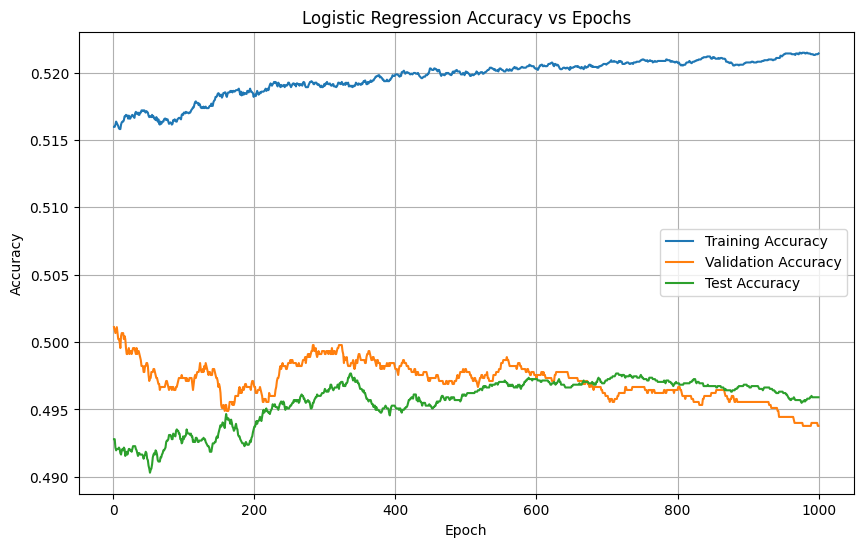

In [11]:
epochs = range(1, len(train_accuracies) + 1)

plt.figure(figsize=(10, 6))

plt.plot(epochs, train_accuracies, label="Training Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.plot(epochs, test_accuracies, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Logistic Regression Accuracy vs Epochs")

plt.legend()
plt.grid(True)
plt.show()

In [12]:
final_test_probabilities = sigmoid(
    np.dot(X_test_scaled, weights) + bias
)

final_test_predictions = (
    final_test_probabilities >= 0.5
).astype(int)

final_test_labels = np.where(
    final_test_predictions == 1,
    "Yes",
    "No"
)

predictions = pd.DataFrame({
    "Num": test_processed["Num"],
    "closed": final_test_labels
})

print(predictions.head(10))
print(predictions["closed"].value_counts())
print("Total predictions:", len(predictions))

     Num closed
0  32080     No
1  39120    Yes
2  34554     No
3  29685    Yes
4  20674    Yes
5  37947    Yes
6  22118     No
7   8428    Yes
8  24360     No
9  32391    Yes
closed
No     4859
Yes    4780
Name: count, dtype: int64
Total predictions: 9639


In [13]:
predictions.to_csv("crime_predictions.csv", index=False)

print("crime_predictions.csv saved")

crime_predictions.csv saved
